In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

외국인 근로자 현황

In [24]:
#국적 미취득 외국인 근로자

forwork = pd.read_csv("한국 국적 미취득 외국인 근로자.csv",encoding='cp949')
forwork = forwork.set_index('시점')
forwork

,소계,동북아시아 소계,중국,중국(한국계),대만,일본,몽골,동남아시아 소계,베트남,필리핀,...,캐나다,유럽 소계,러시아,러시아(한국계),영국,기타.3,오세아니아,중남미,아프리카,기타.4
시점,,,,,,,,,,,,,,,,,,,,,
2015,9956,4401,150,4097,-,8,146,3515,662,392,...,-,-,11,-,-,-,-,-,-,94
2016,9450,3698,115,3448,*,13,120,3477,551,425,...,21,55,8,*,15,30,9,*,23,*
2017,9046,3189,102,2971,*,11,104,3367,541,370,...,29,46,6,*,10,30,8,*,28,*
2018,9288,3289,98,3080,*,8,102,3380,549,365,...,23,38,8,*,9,21,9,*,23,*
2019,8589,2910,96,2724,*,6,84,3252,540,369,...,26,37,5,*,10,22,*,*,20,*
2020,7415,2302,74,2133,*,11,83,2878,530,343,...,21,49,5,*,14,30,*,*,17,*
2021,6621,1862,66,1702,*,8,86,2714,503,314,...,22,41,6,*,17,18,5,*,23,*


In [25]:
forwork.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7 entries, 2015 to 2021
Data columns (total 41 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   소계        7 non-null      int64 
 1   동북아시아 소계  7 non-null      int64 
 2   중국        7 non-null      int64 
 3   중국(한국계)   7 non-null      int64 
 4   대만        7 non-null      object
 5   일본        7 non-null      int64 
 6   몽골        7 non-null      int64 
 7   동남아시아 소계  7 non-null      int64 
 8   베트남       7 non-null      int64 
 9   필리핀       7 non-null      int64 
 10  태국        7 non-null      int64 
 11  인도네시아     7 non-null      int64 
 12  캄보디아      7 non-null      int64 
 13  미얀마       7 non-null      int64 
 14  말레이시아     7 non-null      object
 15  라오스       7 non-null      object
 16  동티모르      7 non-null      object
 17  기타        7 non-null      object
 18  서남아시아 소계  7 non-null      int64 
 19  스리랑카      7 non-null      object
 20  파키스탄      7 non-null      object
 21  방글라데시     7 no

In [26]:
forsum = forwork[['소계','동북아시아 소계','동남아시아 소계','서남아시아 소계','중앙아시아 소계','아시아(기타)','미국','캐나다','유럽 소계','오세아니아','중남미','아프리카','기타.4']]

In [27]:
forsum.replace(['*', '-'], 0, inplace=True)
forsum

<ipython-input-27-28d473be853b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forsum.replace(['*', '-'], 0, inplace=True)


,소계,동북아시아 소계,동남아시아 소계,서남아시아 소계,중앙아시아 소계,아시아(기타),미국,캐나다,유럽 소계,오세아니아,중남미,아프리카,기타.4
시점,,,,,,,,,,,,,
2015,9956,4401,3515,1123,642,0,170,0,0,0,0,0,94
2016,9450,3698,3477,1180,821,0,164,21,55,9,0,23,0
2017,9046,3189,3367,1304,914,0,160,29,46,8,0,28,0
2018,9288,3289,3380,1367,991,0,165,23,38,9,0,23,0
2019,8589,2910,3252,1312,867,0,160,26,37,0,0,20,0
2020,7415,2302,2878,1257,719,0,167,21,49,0,0,17,0
2021,6621,1862,2714,1172,610,0,168,22,41,5,0,23,0


<Figure size 1000x600 with 0 Axes>

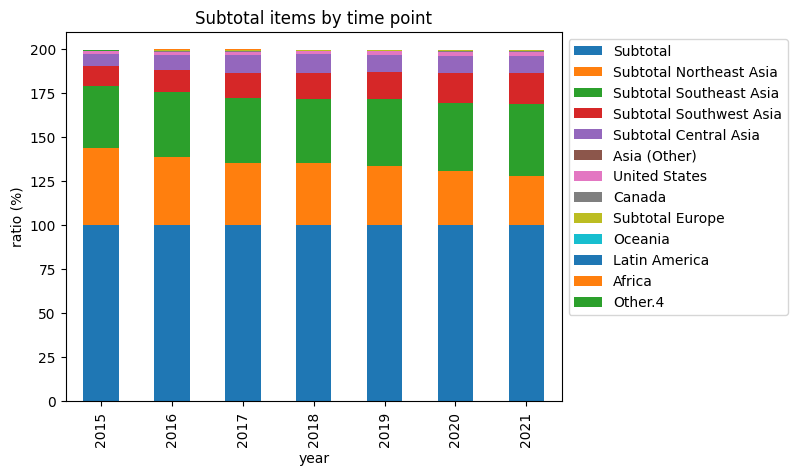

In [29]:
# 수치로 변환
forsum = forsum.apply(pd.to_numeric, errors='coerce')
# 열 이름 변경
new_column_names = {
    '시점' : 'Year',
    '소계': 'Subtotal',
    '동북아시아 소계': 'Subtotal Northeast Asia',
    '동남아시아 소계': 'Subtotal Southeast Asia',
    '서남아시아 소계': 'Subtotal Southwest Asia',
    '중앙아시아 소계': 'Subtotal Central Asia',
    '아시아(기타)': 'Asia (Other)',
    '미국': 'United States',
    '캐나다': 'Canada',
    '유럽 소계': 'Subtotal Europe',
    '오세아니아': 'Oceania',
    '중남미': 'Latin America',
    '아프리카': 'Africa',
    '기타.4': 'Other.4'
}
forsum.rename(columns=new_column_names, inplace=True)

# 소계 및 각 소계 항목 컬럼 선택
subtotal_columns = ['Subtotal', 'Subtotal Northeast Asia', 'Subtotal Southeast Asia', 'Subtotal Southwest Asia', 'Subtotal Central Asia', 'Asia (Other)', 'United States', 'Canada', 'Subtotal Europe', 'Oceania', 'Latin America', 'Africa', 'Other.4']


# 소계 항목의 비율 계산
forsum_ratios = forsum[subtotal_columns].div(forsum['Subtotal'], axis=0) * 100

# 누적 막대 그래프 그리기
plt.figure(figsize=(10, 6))
forsum_ratios.plot(kind='bar', stacked=True)
plt.title("Subtotal items by time point")
plt.xlabel("year")
plt.ylabel("ratio (%)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

동북아시아 근로자는 비교적 점점 줄어드는 추세에 반면 동남아시아, 서남아시아, 중앙아시아는 비교적 늘어나는 추세로 볼 수 있다.

In [45]:
#농가에서 근로한 외국인 근로자

farmfor = pd.read_csv("고용기간_및_내_·_외국인_성별·고용인수별_농가_20230811191552.csv",encoding='cp949')
farmfor = farmfor.set_index('시점')
new_column_names = {
    '시점' : 'Year',
    '3~6개월:계': '3~6month all',
    '외국인 남자_소계': '3~6month man',
    '외국인 여자_소계': '3~6month woman',
    '6개월이상:계': '6month+ all',
    '외국인 남자_소계.1': '6month+ man',
    '외국인 여자_소계.1': '6month+ woman'
}
farmfor.rename(columns=new_column_names, inplace=True)
farmfor

,3~6month all,3~6month man,3~6month woman,6month+ all,6month+ man,6month+ woman
시점,,,,,,
2015,75,23,8,193,108,62
2020,68,27,15,212,112,63


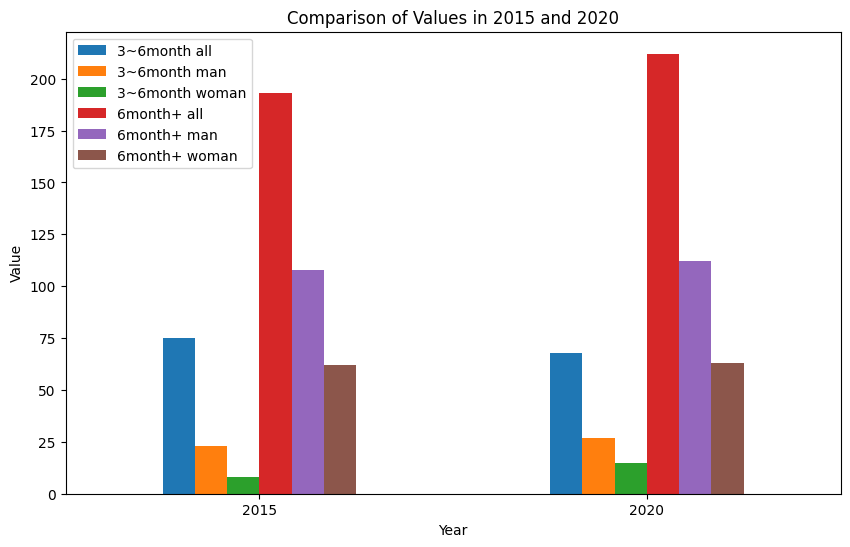

In [49]:

farmfor.plot(kind='bar', figsize=(10, 6))
plt.title("Comparison of Values in 2015 and 2020")
plt.xlabel("Year")
plt.ylabel("Value")
plt.xticks(rotation=0)  # X축 레이블 회전 없이 표시
plt.legend(loc='upper left')
plt.show()

다른 것들은 대부분 비슷하지만 농가에서 6개월 이상 일한 외국인 근로자의 수가 늘어난 것이 확연하게 보인다. 또, 농가에서 3~6개월 일한 여성 외국인 근로자의 수도 늘어났다.

##외국인 토지 및 건축물 거래

In [60]:
forland = pd.read_csv("외국인 토지 거래.csv",encoding='cp949')
forland = forland.set_index('시점')
forland

,필지 (필지),면적 (천㎡)
시점,,
2015.01,13,1
2015.02,6,1
2015.03,12,5
2015.04,10,1
2015.05,13,1
...,...,...
2023.01,34,1
2023.02,51,2
2023.03,53,6


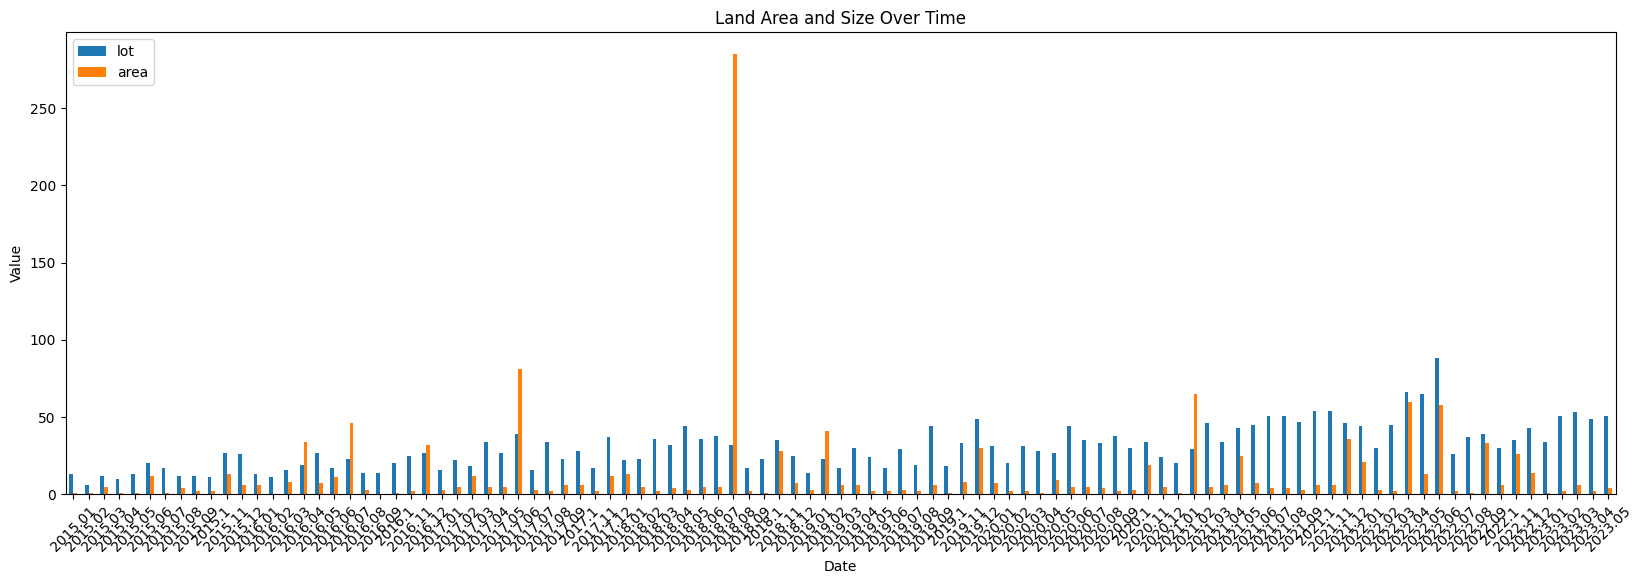

In [64]:
forland.plot(kind='bar', figsize=(20, 6))
plt.title("Land Area and Size Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=45)  # X축 레이블을 45도 회전하여 표시
plt.legend(('lot','area'),loc='upper left')
plt.show()

In [69]:
forland.max()

필지 (필지)     88
면적 (천㎡)    285
dtype: int64

외국인의 필지 거래량이 가장 많았던 시기는 2022년 5월이고 거래 면적이 가장 넓었던 시기는 2018년 7월이다. 시간의 흐름과는 별로 연관되어 보이지 않는다.

In [66]:
forld = pd.read_csv("외국인 순수 토지 거래.csv",encoding='cp949')
forld = forld.set_index('시점')
forld

,필지 (필지),면적 (천㎡)
시점,,
2015.01,4,1
2015.02,0,0
2015.03,4,5
2015.04,2,0
2015.05,0,0
...,...,...
2023.01,6,0
2023.02,11,0
2023.03,14,5


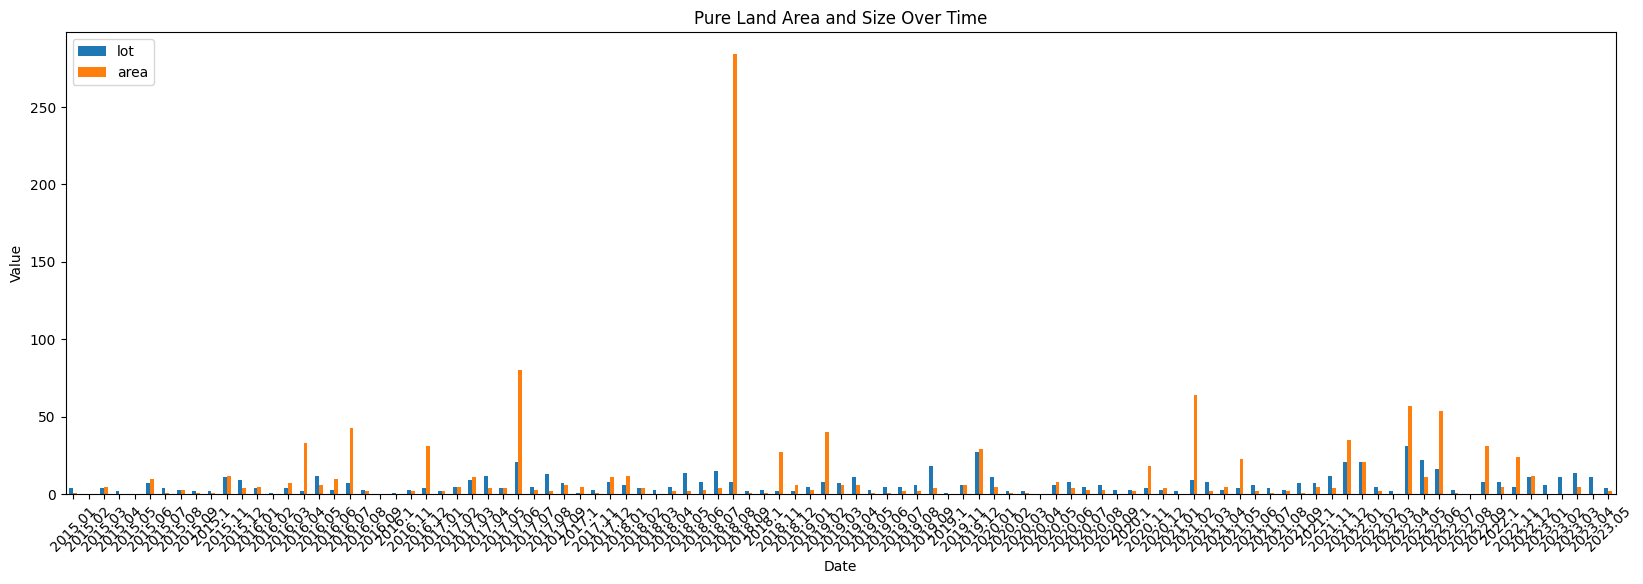

In [67]:
forld.plot(kind='bar', figsize=(20, 6))
plt.title("Pure Land Area and Size Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=45)  # X축 레이블을 45도 회전하여 표시
plt.legend(('lot','area'),loc='upper left')
plt.show()

In [68]:
forld.max()

필지 (필지)     31
면적 (천㎡)    284
dtype: int64

필지가 가장 많이 거래되었던 시기는 2022년 3월이고 가장 넓은 면적이 거래되었던 시기는 2018년 7월이다.

In [74]:
forto = pd.read_csv("외국인 건축물 거래.csv",encoding='cp949')
forto = forto.set_index('시점')
new_column_names = {
    '시점' : 'Year',
    '동(호)수 (동(호)수)': '동(호)수',
    '면적 (천㎡)': '면적 (천㎡)',
}
forto.rename(columns=new_column_names, inplace=True)
forto

,동(호)수,면적 (천㎡)
시점,,
2015.01,10,1
2015.02,6,1
2015.03,8,1
2015.04,8,1
2015.05,13,1
...,...,...
2023.01,29,5
2023.02,40,2
2023.03,40,3


In [75]:
forto.max()

동(호)수      72
면적 (천㎡)     7
dtype: int64

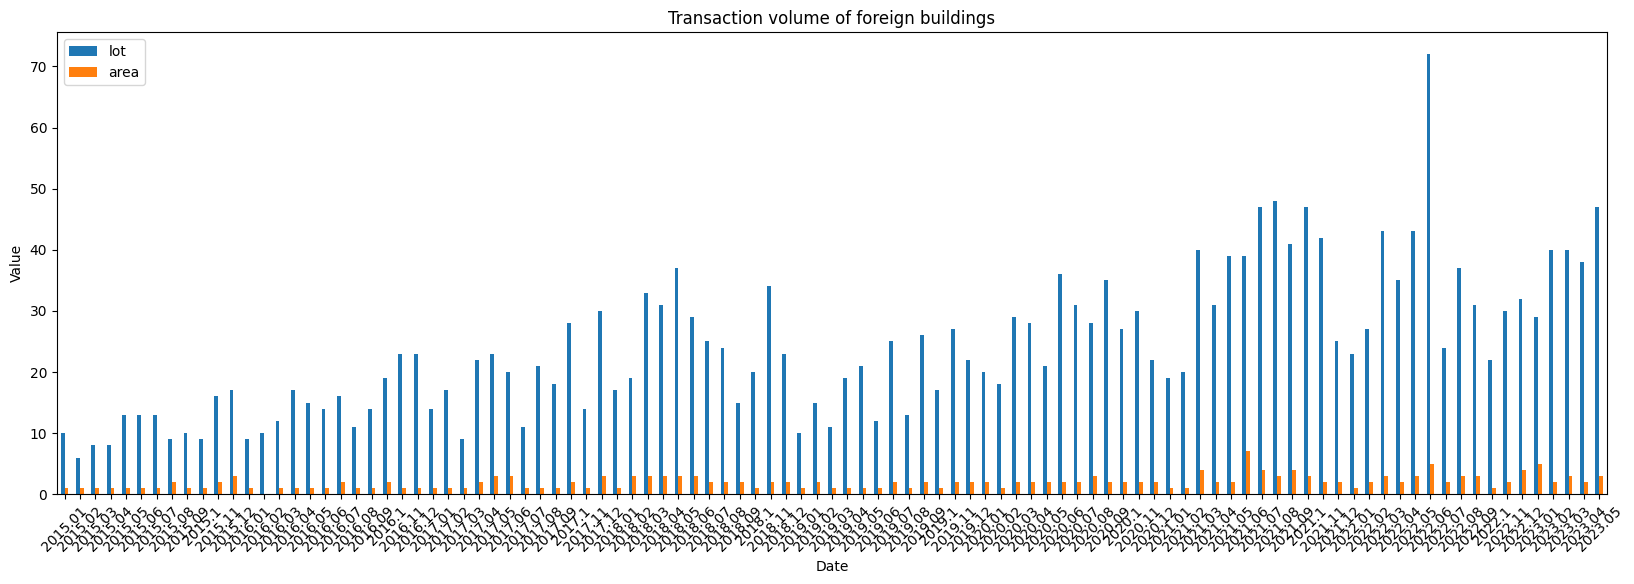

In [82]:
forto.plot(kind='bar', figsize=(20, 6))
plt.title("Transaction volume of foreign buildings")
plt.xlabel("Date")
plt.ylabel("Value")
plt.xticks(rotation=45)  # X축 레이블을 45도 회전하여 표시
plt.legend(('lot','area'),loc='upper left')
plt.show()

2022년 5월 가장 많은 거래량이 일어났다. 또 전체적으로 보았을 때 2021년 이후로 평균적인 거래량이 늘어난 것으로 보인다.

In [83]:
foronly = pd.read_csv("외국인 단독주택.csv",encoding='cp949')
foronly = foronly.set_index('시점')
foronly

,주택수 (동수),지분반영 주택수 (동수),소유자수 (명),1인당 평균소유주택수 (동수),지분반영 1인당 평균소유주택수 (동수)
시점,,,,,
2022.2/2,77,69,84,0.92,0.82


In [84]:
forwith = pd.read_csv("외국인 공동주택.csv",encoding='cp949')
forwith = forwith.set_index('시점')
forwith

,주택수 (호수),지분반영 주택수 (호수),소유자수 (명),1인당 평균소유주택수 (호수),지분반영 1인당 평균소유주택수 (호수)
시점,,,,,
2022.2/2,1555,1482,1470,1.06,1.01
